# 06f — Direct Evidence Precision Audit

本 notebook 是进入付费 07 前的最后一层免费证据精度检查。

它直接读取 06e 的输出，不重新构建知识库，也不调用 LLM/API。核心目标是纠正 06e 对 `direct_policy_evidence` 的过度判定：

- 一个普通词重合不再构成直接证据；
- manifesto 必须覆盖多个有区分力的政策词；
- 同一 Bill 的早期投票，对整部 Bill 可以是直接证据，对具体 Clause 通常只能作为背景；
- Bill reference 只提供背景，不提供政党立场；
- 已知正确和错误案例组成小型人工 gold set，用于检验规则本身。

In [25]:
# 导入文本处理、表格分析和绘图所需的库。
from pathlib import Path
from collections import Counter
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 180)
pd.set_option('display.width', 260)
pd.set_option('display.max_colwidth', 240)

NOTEBOOK_VERSION = '06f-rag-direct-precision-v5.2'
RANDOM_STATE = 42

ROOT = Path.cwd()
MODEL_DIR = ROOT / 'processed' / 'model_v2'
RAG_V3_DIR = ROOT / 'processed' / 'rag_v3'
AUDIT_V4_DIR = ROOT / 'processed' / 'rag_audit_v4'
AUDIT_V5_DIR = ROOT / 'processed' / 'rag_audit_v5'
AUDIT_V5_DIR.mkdir(parents=True, exist_ok=True)

VALIDATION_PATH = MODEL_DIR / 'model_validation_v2.csv'
CHUNKS_PATH = RAG_V3_DIR / 'rag_chunks_v3.csv'
V4_EVIDENCE_PATH = AUDIT_V4_DIR / 'retrieval_v4_evidence.csv'
V4_QUERY_PATH = AUDIT_V4_DIR / 'retrieval_v4_query_metrics.csv'
V4_GAP_PATH = AUDIT_V4_DIR / 'corpus_gap_queries_v4.csv'

print('Notebook version:', NOTEBOOK_VERSION)
print('API calls enabled: False')
print('LLM calls enabled: False')
print('Rebuilds knowledge base: False')

Notebook version: 06f-rag-direct-precision-v5.2
API calls enabled: False
LLM calls enabled: False
Rebuilds knowledge base: False


## 1. Load V4 evidence

06f 只重新判断证据角色，不修改 06e 的原始相似度分数，也不改变投票标签。

In [26]:
# 读取验证集法案名称、完整知识库、v4候选证据和查询级结果。
validation = pd.read_csv(VALIDATION_PATH, low_memory=False)
chunks = pd.read_csv(CHUNKS_PATH, low_memory=False)
evidence_v4 = pd.read_csv(V4_EVIDENCE_PATH, low_memory=False)
queries_v4 = pd.read_csv(V4_QUERY_PATH, low_memory=False)
gaps_v4 = pd.read_csv(V4_GAP_PATH, low_memory=False)

for frame, column in [
    (validation, 'motion_date'),
    (chunks, 'source_date'),
    (evidence_v4, 'query_date'),
    (evidence_v4, 'evidence_date'),
    (queries_v4, 'query_date'),
]:
    frame[column] = pd.to_datetime(frame[column], errors='coerce')

# Clause标题经常不含Bill名称，因此从验证集补回查询法案名称。
query_legislation = (
    validation.sort_values(['division_key', 'party'])
    .drop_duplicates('division_key')[
        ['division_key', 'legislation_name_clean']
    ]
    .rename(columns={'legislation_name_clean': 'query_legislation_name'})
)
evidence_v4 = evidence_v4.merge(
    query_legislation,
    left_on='query_division_key',
    right_on='division_key',
    how='left',
    validate='many_to_one',
).drop(columns='division_key')

assert len(queries_v4) == 96
assert evidence_v4['query_id'].nunique() <= 96
assert not evidence_v4.duplicated(['query_id', 'evidence_chunk_id']).any()

display(pd.DataFrame({
    'dataset': ['knowledge_base', 'v4_evidence', 'v4_queries'],
    'rows': [len(chunks), len(evidence_v4), len(queries_v4)],
}))

,dataset,rows
0,knowledge_base,4942
1,v4_evidence,454
2,v4_queries,96


## 2. Canonical policy tokens

06e 会把同义词扩展成多个词，因此短查询可能因为一个普通词得到过高覆盖率。06f 改为把同义表达压缩成同一个 canonical token，例如：

- `value added tax` → `vat`
- `private school` / `independent school` → `private_school`
- `two-child cap` / `two-child limit` → `two_child_limit`
- `smoking` / `cigarette` / `tobacco` → `tobacco`

In [27]:
# 定义文本清理、同义词归一和程序词删除规则。
def safe_text(value):
    # 将缺失值安全转换为空字符串。
    if pd.isna(value):
        return ''
    return re.sub(r'\s+', ' ', str(value)).strip()


CANONICAL_PATTERNS = [
    (r'\bvalue[ -]?added tax\b|\bvat\b', ' vat '),
    (r'\bprivate schools?\b|\bindependent schools?\b', ' private_school '),
    (r'\btwo[ -]?child (?:limit|cap)\b', ' two_child_limit '),
    (r'\bgeneral practitioners?\b|\bgps?\b', ' general_practitioner '),
    (r'\bnational insurance contributions?\b|\bnics?\b', ' national_insurance '),
    (r'\bsecondary class 1 contributions?\b', ' employer_national_insurance '),
    (r'\brailways?\b|\brailroads?\b', ' railway '),
    (r'\bvapes?\b|\bvaping\b|\belectronic cigarettes?\b', ' vaping '),
    (r'\btobacco\b|\bcigarettes?\b|\bsmoking\b', ' tobacco '),
    (r'\bjobs?\b', ' job '),
    (r'\bcreation\b|\bcreating\b|\bcreated\b|\bcreate\b', ' create '),
]

PROCEDURAL_PATTERNS = [
    r'\bfirst reading\b', r'\bsecond reading\b', r'\bthird reading\b',
    r'\bcommencement\b', r'\bquestion put\b', r'\bstanding order\b',
    r'\bthat the bill be now read\b', r'\bthat the clause stand part\b',
    r'\bnew clause\s*\d*\b', r'\bclause\s*\d+\b',
    r'\bamendment proposed\b', r'\bamendment\b',
    r'\bi beg to move\b', r'\bthe house\b',
]

GENERIC_POLICY_WORDS = {
    'british', 'united', 'kingdom', 'people', 'government', 'future',
    'support', 'supporting', 'supported', 'ensure', 'including', 'include',
    'provide', 'providing', 'make', 'making', 'work', 'working', 'change',
    'plan', 'plans', 'policy', 'policies', 'country', 'national', 'local',
    'new', 'current', 'year', 'years', 'public', 'service', 'services',
    'bill', 'act', 'order', 'motion', 'reading', 'clause', 'amendment',
    'question', 'house', 'commons', 'approve', 'proposed', 'stage',
    'page', 'line', 'section', 'part', 'paragraph', 'schedule', 'great',
    'use', 'used', 'using', 'expected', 'expect', 'increase', 'increased',
    'number', 'rate', 'rates', 'relief',
}
TOKEN_STOP_WORDS = set(ENGLISH_STOP_WORDS).union(GENERIC_POLICY_WORDS)

# 单一领域词只能让证据成为context，不能单独成为direct。
DOMAIN_CONTEXT_TOKENS = {
    'energy', 'renewable', 'railway', 'farming', 'agriculture',
    'tobacco', 'vaping', 'vat', 'private_school', 'housing',
    'health', 'welfare', 'pension', 'immigration', 'asylum',
    'education', 'employment', 'tax', 'national_insurance',
}


def canonical_text(value):
    # 将同义表达压缩为统一政策词，并去除程序短语。
    text = safe_text(value).lower().replace('__', ' ')
    for pattern in PROCEDURAL_PATTERNS:
        text = re.sub(pattern, ' ', text, flags=re.IGNORECASE)
    for pattern, replacement in CANONICAL_PATTERNS:
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
    text = re.sub(r'[^a-z0-9_£%\- ]+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()


def ordered_policy_tokens(value):
    # 按原顺序保留有政策含义的词。
    return [
        token for token in re.findall(r'[a-z_][a-z0-9_\-]{2,}', canonical_text(value))
        if token not in TOKEN_STOP_WORDS
    ]


def policy_token_set(value):
    # 将政策词转换为集合，用于计算匹配数量。
    return set(ordered_policy_tokens(value))


def entity_token_set(value):
    # Bill实体匹配保留Great和British等正式名称词。
    text = canonical_text(value)
    entity_stop = set(ENGLISH_STOP_WORDS).union({
        'bill', 'act', 'order', 'reading', 'clause', 'amendment',
        'proposed', 'stage', 'page', 'line', 'section', 'part',
    })
    return {
        token for token in re.findall(r'[a-z_][a-z0-9_\-]{2,}', text)
        if token not in entity_stop
    }


def policy_ngrams(value, sizes=(2, 3)):
    # 生成政策双词和三词短语，避免单一普通词触发直接证据。
    tokens = ordered_policy_tokens(value)
    result = set()
    for size in sizes:
        result.update(
            tuple(tokens[index:index + size])
            for index in range(len(tokens) - size + 1)
        )
    return result

## 3. Estimate token distinctiveness from the full corpus

政策词如果出现在大量知识库 chunk 中，区分力较低。06f 使用整个已有语料的 document frequency 识别高频词，但不会读取未来投票标签。

In [28]:
# 计算每个政策词在多少知识库chunk中出现。
corpus_document_frequency = Counter()
for value in chunks['retrieval_text'].fillna('').astype(str):
    corpus_document_frequency.update(policy_token_set(value))

CORPUS_SIZE = len(chunks)
DISTINCTIVE_MAX_DOCUMENT_RATE = 0.10


def is_distinctive(token):
    # 将出现在不超过10%语料中的词视为有区分力。
    return (
        corpus_document_frequency.get(token, 0) / max(CORPUS_SIZE, 1)
        <= DISTINCTIVE_MAX_DOCUMENT_RATE
    )


token_frequency_audit = pd.DataFrame(
    corpus_document_frequency.most_common(30),
    columns=['token', 'document_frequency'],
)
token_frequency_audit['document_rate'] = (
    token_frequency_audit['document_frequency'] / CORPUS_SIZE
)
display(token_frequency_audit)

,token,document_frequency,document_rate
0,lords,1203,0.243424
1,disagrees,988,0.199919
2,disagree,901,0.182315
3,time,835,0.168960
4,laid,742,0.150142
5,approved,728,0.147309
6,regulations,639,0.129300
7,end,578,0.116957
8,draft,569,0.115136
9,union,504,0.101983


## 4. Recalculate evidence specificity

证据角色定义：

- `directional_direct`：可以直接用于判断该党对当前政策对象的方向；
- `relevant_context`：与同一政策或法案相关，但不能单独推出当前立场；
- `background_reference`：只提供法案定义或制度背景；
- `reject_low_specificity`：匹配主要来自普通词或程序词，不进入 LLM context。

In [29]:
# 判断查询属于整部法案、具体条款还是普通政策动议。
def query_scope(title):
    # 具体Clause和Amendment需要比整部Bill更严格的直接证据。
    value = safe_text(title).lower()
    if re.search(r'\b(?:new )?clause\b|\bamendment\b', value):
        return 'provision_level'
    if re.search(r'\b(?:first|second|third) reading\b|\bbill introduction\b', value):
        return 'bill_level'
    return 'policy_motion'


def extract_bill_key(value):
    # 从标题、政策对象或证据文本中提取最长的Bill名称。
    text = safe_text(value)
    matches = re.findall(
        r'([A-Za-z0-9][A-Za-z0-9()\'’&,.\- ]{2,140}?\bBill)\b',
        text,
        flags=re.IGNORECASE,
    )
    if not matches:
        return ''
    # 选择实体词最多的候选，避免把“I beg to move, That the Bill”当成法案名。
    candidate = max(
        matches,
        key=lambda value: (
            len(entity_token_set(canonical_text(value))),
            -len(value),
        ),
    )
    return canonical_text(candidate)


def same_bill(query_value, evidence_value):
    # 比较查询和证据是否指向同一部Bill。
    query_key = extract_bill_key(query_value)
    evidence_key = extract_bill_key(evidence_value)
    if not query_key or not evidence_key:
        return False
    query_tokens = entity_token_set(query_key)
    evidence_tokens = entity_token_set(evidence_key)
    if not query_tokens or not evidence_tokens:
        return False
    overlap = len(query_tokens & evidence_tokens)
    return overlap >= 2 and (
        query_tokens.issubset(evidence_tokens)
        or evidence_tokens.issubset(query_tokens)
        or overlap / min(len(query_tokens), len(evidence_tokens)) >= 0.80
    )


def query_anchor(row):
    # 以政策对象为主，标题和法案名只提供补充实体信息。
    return ' '.join([
        safe_text(row.get('effective_policy_object')),
        safe_text(row.get('query_title')),
        safe_text(row.get('query_legislation_name')),
    ])


def evidence_anchor(row):
    # 证据锚点使用标题和正文，不使用分数或预测标签。
    return ' '.join([
        safe_text(row.get('evidence_title')),
        safe_text(row.get('evidence_text')),
    ])


def specificity_features(row):
    # 计算词匹配、短语匹配、同Bill关系和查询层级。
    query_value = query_anchor(row)
    evidence_value = evidence_anchor(row)
    query_tokens = policy_token_set(query_value)
    evidence_tokens = policy_token_set(evidence_value)
    matched_tokens = query_tokens & evidence_tokens
    distinctive_matches = {
        token for token in matched_tokens if is_distinctive(token)
    }
    phrase_matches = policy_ngrams(query_value) & policy_ngrams(evidence_value)
    coverage = (
        len(distinctive_matches) / len({
            token for token in query_tokens if is_distinctive(token)
        })
        if any(is_distinctive(token) for token in query_tokens)
        else 0.0
    )
    query_bill_value = query_value
    evidence_bill_value = evidence_value
    return pd.Series({
        'query_scope_v5': query_scope(row.get('query_title')),
        'query_policy_token_count': len(query_tokens),
        'matched_policy_token_count': len(matched_tokens),
        'matched_distinctive_token_count': len(distinctive_matches),
        'matched_phrase_count': len(phrase_matches),
        'distinctive_coverage': coverage,
        'matched_policy_tokens': ' | '.join(sorted(matched_tokens)),
        'matched_distinctive_tokens': ' | '.join(sorted(distinctive_matches)),
        'same_bill_v5': same_bill(query_bill_value, evidence_bill_value),
    })


evidence_rules = pd.concat(
    [evidence_v4.copy(), evidence_v4.apply(specificity_features, axis=1)],
    axis=1,
)
display(evidence_rules[[
    'query_title', 'query_party', 'source_type', 'evidence_title',
    'matched_distinctive_token_count', 'matched_phrase_count',
    'distinctive_coverage', 'same_bill_v5'
]].head(12))

,query_title,query_party,source_type,evidence_title,matched_distinctive_token_count,matched_phrase_count,distinctive_coverage,same_bill_v5
0,Immigration and Home Affairs,conservative,historical_vote,A Plan for the NHS and Social Care,4,1,0.500,False
1,Immigration and Home Affairs,conservative,historical_vote,Economy and Jobs,2,0,0.250,False
2,Immigration and Home Affairs,conservative,historical_vote,The Economy,3,0,0.375,False
3,Immigration and Home Affairs,conservative,historical_vote,Cost of Living,3,1,0.375,False
4,Immigration and Home Affairs,conservative,manifesto,Conservative and Unionist Party Manifesto 2024 | Page 24,3,1,0.375,False
5,Immigration and Home Affairs,green,historical_vote,A Plan for the NHS and Social Care,4,1,0.500,False
6,Immigration and Home Affairs,green,historical_vote,Economy and Jobs,2,0,0.250,False
7,Immigration and Home Affairs,green,historical_vote,The Economy,3,0,0.375,False
8,Immigration and Home Affairs,green,historical_vote,Cost of Living,3,1,0.375,False
9,Immigration and Home Affairs,green,manifesto,Green Party 2024 General Election Manifesto | • Abolish the two-child benefit cap and lift,0,0,0.000,False


In [30]:
# 按来源和查询层级重新分配证据角色。
def classify_evidence_role(row):
    # Bill reference永远不能单独代表政党立场。
    source = row['source_type']
    scope = row['query_scope_v5']
    distinct = int(row['matched_distinctive_token_count'])
    phrase = int(row['matched_phrase_count'])
    coverage = float(row['distinctive_coverage'])
    base = float(row['base_score'])
    same_bill_flag = bool(row['same_bill_v5'])
    matched_token_values = {
        token for token in safe_text(
            row.get('matched_policy_tokens')
        ).split(' | ') if token
    }

    if source == 'bill_reference':
        if same_bill_flag or (distinct >= 2 and coverage >= 0.30):
            return 'background_reference'
        return 'reject_low_specificity'

    if source == 'manifesto':
        # 具体法律文书不能只凭上位主题词推断立场。
        legal_instrument = bool(re.search(
            r'\b(?:act|order|statutory instrument)\b',
            safe_text(row.get('query_title')).lower(),
        ))
        if scope == 'provision_level':
            direct = (
                distinct >= 2 and phrase >= 1
                and coverage >= 0.18 and base >= 0.040
            )
            context = (
                distinct >= 2 and base >= 0.045
                and (phrase >= 1 or coverage >= 0.40)
            ) or (
                bool(matched_token_values & DOMAIN_CONTEXT_TOKENS)
                and base >= 0.040
            )
        elif legal_instrument:
            direct = (
                distinct >= 3 and phrase >= 1
                and coverage >= 0.50 and base >= 0.050
            )
            context = (
                distinct >= 3 and base >= 0.055
                and (phrase >= 1 or coverage >= 0.50)
            )
        else:
            direct = (
                distinct >= 2 and base >= 0.040
                and (phrase >= 1 or coverage >= 0.40)
            )
            context = (
                distinct >= 2 and base >= 0.040
                and (phrase >= 1 or coverage >= 0.30)
            ) or (
                distinct == 1 and coverage >= 0.50 and base >= 0.080
            )
        if direct:
            return 'directional_direct'
        if context:
            return 'relevant_context'
        return 'reject_low_specificity'

    if source == 'historical_vote':
        # 对整部Bill的预测，早期相同Bill投票可以直接提供方向。
        if scope == 'bill_level' and same_bill_flag:
            return 'directional_direct'

        # 对具体条款，只在证据同时命中多个具体政策词时才视为直接。
        provision_direct = (
            scope == 'provision_level'
            and distinct >= 3
            and base >= 0.070
            and (phrase >= 1 or coverage >= 0.45)
        )
        policy_direct = (
            scope == 'policy_motion'
            and distinct >= 2
            and base >= 0.060
            and (phrase >= 1 or coverage >= 0.40)
        )
        if provision_direct or policy_direct:
            return 'directional_direct'
        if same_bill_flag or (
            distinct >= 2 and base >= 0.050
            and (phrase >= 1 or coverage >= 0.30)
        ) or (
            distinct == 1 and coverage >= 0.50 and base >= 0.100
        ):
            return 'relevant_context'
        return 'reject_low_specificity'

    return 'reject_low_specificity'


evidence_rules['evidence_role_v5'] = evidence_rules.apply(
    classify_evidence_role, axis=1
)
evidence_rules['role_changed_from_v4'] = (
    evidence_rules['evidence_role_auto'].eq('direct_policy_evidence')
    & evidence_rules['evidence_role_v5'].ne('directional_direct')
)

role_transition = pd.crosstab(
    evidence_rules['evidence_role_auto'],
    evidence_rules['evidence_role_v5'],
)
display(role_transition)

evidence_role_v5,background_reference,directional_direct,reject_low_specificity,relevant_context
evidence_role_auto,,,,
contextual_evidence,0,3,35,4
direct_policy_evidence,12,152,182,66


## 5. Gold-set regression audit

下面的案例来自 06d–06e 的人工检查。它同时包含应该保留的证据和已确认的误检。规则必须区分两者，不能只追求召回数量。

In [31]:
# 建立已人工确认的正反例，作为证据角色回归测试。
gold_cases = pd.DataFrame([
    {
        'case_id': 'green_energy_migration_reject',
        'division_key': 'pw-2024-10-29-24-commons',
        'party': 'green', 'source_type': 'manifesto',
        'pattern': r'fleeing persecution|migration is inevitable',
        'expected_role': 'reject_low_specificity', 'critical': True,
    },
    {
        'case_id': 'green_energy_renewable_context',
        'division_key': 'pw-2024-10-29-24-commons',
        'party': 'green', 'source_type': 'manifesto',
        'pattern': r'Sourcing renewable energy',
        'expected_role': 'relevant_context', 'critical': True,
    },
    {
        'case_id': 'green_clause_bill_stage_context',
        'division_key': 'pw-2024-10-29-24-commons',
        'party': 'green', 'source_type': 'historical_vote',
        'pattern': r'Second Reading: Great British Energy Bill',
        'expected_role': 'relevant_context', 'critical': True,
    },
    {
        'case_id': 'green_third_reading_prior_stage_direct',
        'division_key': 'pw-2024-10-29-27-commons',
        'party': 'green', 'source_type': 'historical_vote',
        'pattern': r'Second Reading: Great British Energy Bill',
        'expected_role': 'directional_direct', 'critical': True,
    },
    {
        'case_id': 'labour_vat_manifesto_direct',
        'division_key': 'pw-2024-11-06-34-commons',
        'party': 'labour', 'source_type': 'manifesto',
        'pattern': r'VAT exemption|business rates relief for private',
        'expected_role': 'directional_direct', 'critical': True,
    },
    {
        'case_id': 'labour_vat_history_direct',
        'division_key': 'pw-2024-11-06-34-commons',
        'party': 'labour', 'source_type': 'historical_vote',
        'pattern': r'VAT: Independent Schools',
        'expected_role': 'directional_direct', 'critical': True,
    },
    {
        'case_id': 'libdem_vat_history_direct',
        'division_key': 'pw-2024-11-06-34-commons',
        'party': 'liberal-democrat', 'source_type': 'historical_vote',
        'pattern': r'VAT: Independent Schools',
        'expected_role': 'directional_direct', 'critical': True,
    },
    {
        'case_id': 'green_tobacco_manifesto_context',
        'division_key': 'pw-2024-11-26-48-commons',
        'party': 'green', 'source_type': 'manifesto',
        'pattern': r'Smoking cessation',
        'expected_role': 'relevant_context', 'critical': True,
    },
    {
        'case_id': 'proportional_representation_investment_zone_reject',
        'division_key': 'pw-2024-12-03-52-commons',
        'party': 'conservative', 'source_type': 'manifesto',
        'pattern': r'Investment Zones',
        'expected_role': 'reject_low_specificity', 'critical': True,
    },
    {
        'case_id': 'renters_rights_railcard_reject',
        'division_key': 'pw-2024-10-09-18-commons',
        'party': 'conservative', 'source_type': 'manifesto',
        'pattern': r'Veterans Railcard',
        'expected_role': 'reject_low_specificity', 'critical': True,
    },
    {
        'case_id': 'farming_access_to_work_reject',
        'division_key': 'pw-2024-10-08-17-commons',
        'party': 'liberal-democrat', 'source_type': 'manifesto',
        'pattern': r'Access to Work',
        'expected_role': 'reject_low_specificity', 'critical': True,
    },
    {
        'case_id': 'farming_national_security_reject',
        'division_key': 'pw-2024-10-08-17-commons',
        'party': 'liberal-democrat', 'source_type': 'historical_vote',
        'pattern': r'National Security Bill: New Clause 9',
        'expected_role': 'reject_low_specificity', 'critical': True,
    },
    {
        'case_id': 'finance_first_time_buyer_reject',
        'division_key': 'pw-2024-12-10-59-commons',
        'party': 'conservative', 'source_type': 'manifesto',
        'pattern': r'first-time|frst-time',
        'expected_role': 'reject_low_specificity', 'critical': True,
    },
    {
        'case_id': 'custodial_period_prisoner_voting_reject',
        'division_key': 'pw-2024-07-25-5-commons',
        'party': 'conservative', 'source_type': 'manifesto',
        'pattern': r'prisoners voting',
        'expected_role': 'reject_low_specificity', 'critical': False,
    },
    {
        'case_id': 'labour_gb_energy_jobs_direct',
        'division_key': 'pw-2024-10-29-24-commons',
        'party': 'labour', 'source_type': 'manifesto',
        'pattern': r'create jobs and home-grown energy|company will create jobs',
        'expected_role': 'directional_direct', 'critical': True,
    },
])


def evaluate_gold_case(case):
    # 查找对应证据，并比较新角色与人工期望角色。
    subset = evidence_rules[
        evidence_rules['query_division_key'].eq(case['division_key'])
        & evidence_rules['query_party'].eq(case['party'])
        & evidence_rules['source_type'].eq(case['source_type'])
    ].copy()
    combined = (
        subset['evidence_title'].fillna('')
        + ' '
        + subset['evidence_text'].fillna('')
    )
    match = subset[
        combined.str.contains(case['pattern'], case=False, regex=True)
    ]
    if match.empty:
        return pd.Series({
            'found': False,
            'observed_role': 'not_found',
            'passed': False,
            'matched_title': '',
        })
    observed = match.iloc[0]
    return pd.Series({
        'found': True,
        'observed_role': observed['evidence_role_v5'],
        'passed': observed['evidence_role_v5'] == case['expected_role'],
        'matched_title': observed['evidence_title'],
    })


gold_results = pd.concat(
    [gold_cases, gold_cases.apply(evaluate_gold_case, axis=1)],
    axis=1,
)
gold_accuracy = gold_results['passed'].mean()
critical_gold_gate = gold_results.loc[
    gold_results['critical'], 'passed'
].all()

display(gold_results)
print('Gold role accuracy:', round(gold_accuracy, 3))
print('Critical gold cases passed:', bool(critical_gold_gate))

,case_id,division_key,party,source_type,pattern,expected_role,critical,found,observed_role,passed,matched_title
0,green_energy_migration_reject,pw-2024-10-29-24-commons,green,manifesto,fleeing persecution|migration is inevitable,reject_low_specificity,True,True,reject_low_specificity,True,Green Party 2024 General Election Manifesto | • The United Kingdom to work with other
1,green_energy_renewable_context,pw-2024-10-29-24-commons,green,manifesto,Sourcing renewable energy,relevant_context,True,True,relevant_context,True,Green Party 2024 General Election Manifesto | Sourcing renewable energy
2,green_clause_bill_stage_context,pw-2024-10-29-24-commons,green,historical_vote,Second Reading: Great British Energy Bill,relevant_context,True,True,relevant_context,True,Second Reading: Great British Energy Bill
3,green_third_reading_prior_stage_direct,pw-2024-10-29-27-commons,green,historical_vote,Second Reading: Great British Energy Bill,directional_direct,True,True,directional_direct,True,Second Reading: Great British Energy Bill
4,labour_vat_manifesto_direct,pw-2024-11-06-34-commons,labour,manifesto,VAT exemption|business rates relief for private,directional_direct,True,True,directional_direct,True,Change — Labour Party Manifesto 2024 | Page 82
5,labour_vat_history_direct,pw-2024-11-06-34-commons,labour,historical_vote,VAT: Independent Schools,directional_direct,True,True,directional_direct,True,VAT: Independent Schools
6,libdem_vat_history_direct,pw-2024-11-06-34-commons,liberal-democrat,historical_vote,VAT: Independent Schools,directional_direct,True,True,directional_direct,True,VAT: Independent Schools
7,green_tobacco_manifesto_context,pw-2024-11-26-48-commons,green,manifesto,Smoking cessation,relevant_context,True,True,relevant_context,True,Green Party 2024 General Election Manifesto | • Restoring public health budgets to 2015/16
8,proportional_representation_investment_zone_reject,pw-2024-12-03-52-commons,conservative,manifesto,Investment Zones,reject_low_specificity,True,True,reject_low_specificity,True,Conservative and Unionist Party Manifesto 2024 | Continue backing Investment Zones across
9,renters_rights_railcard_reject,pw-2024-10-09-18-commons,conservative,manifesto,Veterans Railcard,reject_low_specificity,True,True,reject_low_specificity,True,Conservative and Unionist Party Manifesto 2024 | ❱ We will cut the cost of the Veterans Railcard so that it


Gold role accuracy: 1.0
Critical gold cases passed: True


## 6. Build the filtered LLM evidence set

`reject_low_specificity` 不发送给 LLM。保留的 context 仍会显示，但不能单独触发“证据充分”。

In [32]:
# 删除低区分力证据，并重新计算查询级证据充分性。
evidence_v5 = evidence_rules[
    evidence_rules['evidence_role_v5'].ne('reject_low_specificity')
].copy()

query_recalc_rows = []
for _, query in queries_v4.iterrows():
    subset = evidence_v5[evidence_v5['query_id'].eq(query['query_id'])]
    direct = subset['evidence_role_v5'].eq('directional_direct').sum()
    context = subset['evidence_role_v5'].eq('relevant_context').sum()
    background = subset['evidence_role_v5'].eq('background_reference').sum()
    strong_single = (
        subset['source_type'].eq('historical_vote')
        & subset['evidence_role_v5'].eq('directional_direct')
        & subset['same_bill_v5']
        & subset['query_scope_v5'].eq('bill_level')
    ).any()

    eligible = bool(query['prediction_eligible'])
    if not eligible:
        status = query['query_readiness']
        sufficient = False
    elif direct >= 1 and (len(subset) >= 2 or strong_single):
        status = 'precision_sufficient'
        sufficient = True
    elif direct == 0 and len(subset) == 0:
        status = 'no_relevant_evidence'
        sufficient = False
    elif direct == 0:
        status = 'context_only'
        sufficient = False
    else:
        status = 'single_direct_or_thin_evidence'
        sufficient = False

    query_recalc_rows.append({
        **query.to_dict(),
        'v5_results': len(subset),
        'v5_directional_direct': int(direct),
        'v5_relevant_context': int(context),
        'v5_background_reference': int(background),
        'v5_precision_sufficient': sufficient,
        'v5_evidence_sufficiency': status,
    })

queries_v5 = pd.DataFrame(query_recalc_rows)
eligible_v5 = queries_v5[queries_v5['prediction_eligible']].copy()

display(
    queries_v5['v5_evidence_sufficiency']
    .value_counts()
    .to_frame('queries')
)
display(
    evidence_rules['evidence_role_v5']
    .value_counts()
    .to_frame('evidence_rows')
)

,queries
v5_evidence_sufficiency,
precision_sufficient,56
context_only,19
excluded_multi_issue,8
no_relevant_evidence,7
single_direct_or_thin_evidence,6


,evidence_rows
evidence_role_v5,
reject_low_specificity,217
directional_direct,155
relevant_context,70
background_reference,12


## 7. Party comparison and Green decision

这里比较相同 24 个议案上的证据精度结果。Green 不会因为样本量不同而被单独处罚。

In [33]:
# 按政党汇总严格角色和证据充分率。
party_v5 = (
    queries_v5.groupby('query_party')
    .agg(
        queries=('query_id', 'size'),
        eligible_rate=('prediction_eligible', 'mean'),
        precision_sufficient_rate=('v5_precision_sufficient', 'mean'),
        mean_results=('v5_results', 'mean'),
        mean_directional_direct=('v5_directional_direct', 'mean'),
        context_only_queries=(
            'v5_evidence_sufficiency',
            lambda values: values.eq('context_only').sum(),
        ),
    )
    .reset_index()
)

green_rate = party_v5.loc[
    party_v5['query_party'].eq('green'),
    'precision_sufficient_rate'
].iloc[0]
other_rate = party_v5.loc[
    party_v5['query_party'].ne('green'),
    'precision_sufficient_rate'
].mean()
green_gap = green_rate - other_rate

display(party_v5)
print('Green minus other-party mean sufficient rate:', round(green_gap, 3))

,query_party,queries,eligible_rate,precision_sufficient_rate,mean_results,mean_directional_direct,context_only_queries
0,conservative,24,0.916667,0.666667,2.541667,1.708333,3
1,green,24,0.916667,0.583333,2.541667,1.666667,6
2,labour,24,0.916667,0.625000,2.666667,1.708333,4
3,liberal-democrat,24,0.916667,0.458333,2.125000,1.375000,6


Green minus other-party mean sufficient rate: 0.0


## 8. Deterministic manual precision queue

该队列优先包含：

- 从 V4 direct 被降级或删除的证据；
- V5 仍然判定为 directional direct 的证据；
- gold set 涉及的关键查询。

用户不需要自行阅读。运行后可由 Codex 继续审核这个 CSV。

In [34]:
# 从角色改变和保留direct两组中确定性抽取人工审核样本。
changed = evidence_rules[evidence_rules['role_changed_from_v4']].copy()
retained_direct = evidence_rules[
    evidence_rules['evidence_role_v5'].eq('directional_direct')
].copy()

def stratified_sample(frame, n_total):
    # 按政党和来源分层，避免样本只集中在一个政党。
    if frame.empty:
        return frame
    groups = list(frame.groupby(['query_party', 'source_type'], dropna=False))
    per_group = max(1, int(np.ceil(n_total / max(len(groups), 1))))
    pieces = []
    for _, group in groups:
        pieces.append(group.sample(
            n=min(per_group, len(group)),
            random_state=RANDOM_STATE,
        ))
    sampled = pd.concat(pieces, ignore_index=True)
    if len(sampled) > n_total:
        sampled = sampled.sample(n=n_total, random_state=RANDOM_STATE)
    return sampled


manual_queue = pd.concat([
    stratified_sample(changed, 24),
    stratified_sample(retained_direct, 24),
], ignore_index=True).drop_duplicates(['query_id', 'evidence_chunk_id'])

manual_queue['evidence_text_excerpt'] = manual_queue['evidence_text'].map(
    lambda value: safe_text(value)[:1400]
)
manual_queue['manual_relevance'] = ''
manual_queue['manual_evidence_role'] = ''
manual_queue['manual_notes'] = ''

display(manual_queue[[
    'query_division_key', 'query_party', 'query_title', 'source_type',
    'evidence_title', 'evidence_role_auto', 'evidence_role_v5',
    'matched_distinctive_tokens', 'matched_phrase_count'
]].head(20))

,query_division_key,query_party,query_title,source_type,evidence_title,evidence_role_auto,evidence_role_v5,matched_distinctive_tokens,matched_phrase_count
0,pw-2024-07-29-6-commons,conservative,Second Reading: Passenger Railway Services (Public Ownership) Bill,bill_reference,Transport Strikes (Minimum Service Levels) Bill,direct_policy_evidence,reject_low_specificity,,0
1,pw-2024-09-10-14-commons,conservative,Social Security,bill_reference,Social Security (Up-rating of Benefits) Act 2021,direct_policy_evidence,background_reference,security | social,1
2,pw-2024-12-17-72-commons,conservative,New Clause 1: National Insurance Contributions (Secondary Class 1 Contributions) Bill,historical_vote,Second Reading: National Insurance Contributions (Secondary Class 1 Contributions) Bill,direct_policy_evidence,relevant_context,employer_national_insurance | national_insurance,1
3,pw-2024-10-16-20-commons,conservative,Carer — — Allowance,historical_vote,"AUTUMN STATEMENT DISTRIBUTIONAL ANALYSIS, UNIVERSAL CREDIT AND ESA",direct_policy_evidence,relevant_context,allowance,0
4,pw-2024-07-25-5-commons,conservative,Approve: Criminal Justice Act 2003 (Requisite and Minimum Custodial Periods) Order 2024,manifesto,Conservative and Unionist Party Manifesto 2024 | We will maintain the ban on prisoners voting,direct_policy_evidence,reject_low_specificity,criminal | justice,1
5,pw-2024-12-03-52-commons,conservative,Leave for Bill: Elections (Proportional Representation),manifesto,Conservative and Unionist Party Manifesto 2024 | Continue backing Investment Zones across,direct_policy_evidence,reject_low_specificity,bring | england,0
6,pw-2024-07-29-6-commons,green,Second Reading: Passenger Railway Services (Public Ownership) Bill,bill_reference,Transport Strikes (Minimum Service Levels) Bill,direct_policy_evidence,reject_low_specificity,,0
7,pw-2024-09-10-14-commons,green,Social Security,bill_reference,Social Security (Up-rating of Benefits) Act 2021,direct_policy_evidence,background_reference,security | social,1
8,pw-2024-10-09-18-commons,green,Renters' Rights Bill: Reasoned Amendment to Second Reading,historical_vote,Achieving Economic Growth,direct_policy_evidence,reject_low_specificity,rights,0
9,pw-2024-10-16-20-commons,green,Carer — — Allowance,historical_vote,FINANCE (NO. 3) BILL: Basic rate limit and personal allowance,direct_policy_evidence,reject_low_specificity,allowance,0


## 9. Acceptance gates and outputs

本轮不要求证据充分率越高越好。验收重点是：已知正反例能否区分、低区分力证据是否被减少、时间与议案泄漏是否仍为零。

In [35]:
# 计算精度优先的验收门槛。
v4_direct_rows = evidence_rules['evidence_role_auto'].eq(
    'direct_policy_evidence'
).sum()
v5_direct_rows = evidence_rules['evidence_role_v5'].eq(
    'directional_direct'
).sum()
direct_reduction_rate = 1 - v5_direct_rows / max(v4_direct_rows, 1)

acceptance_gates = {
    'gold_role_accuracy_gate': bool(gold_accuracy >= 0.85),
    'critical_gold_gate': bool(critical_gold_gate),
    'direct_overclassification_reduction_gate': bool(
        direct_reduction_rate >= 0.20
    ),
    'temporal_leakage_gate': bool((
        evidence_v5['evidence_date'] < evidence_v5['query_date']
    ).all()),
    'same_division_gate': bool(
        evidence_v5['query_division_key'].ne(
            evidence_v5['evidence_division_key']
        ).fillna(True).all()
    ),
    'green_not_systematically_missing_gate': bool(green_gap >= -0.20),
}

ready_for_manual_signoff = all(acceptance_gates.values())

evidence_rules.to_csv(
    AUDIT_V5_DIR / 'evidence_role_audit_v5.csv', index=False
)
evidence_v5.to_csv(
    AUDIT_V5_DIR / 'llm_evidence_v5.csv', index=False
)
queries_v5.to_csv(
    AUDIT_V5_DIR / 'query_precision_metrics_v5.csv', index=False
)
party_v5.to_csv(
    AUDIT_V5_DIR / 'party_precision_metrics_v5.csv', index=False
)
gold_results.to_csv(
    AUDIT_V5_DIR / 'gold_role_regression_v5.csv', index=False
)
manual_queue.to_csv(
    AUDIT_V5_DIR / 'manual_direct_precision_queue_v5.csv', index=False
)

print('=== DIRECT EVIDENCE PRECISION SUMMARY FOR REVIEW ===')
print('Notebook version:', NOTEBOOK_VERSION)
print('API calls: 0')
print('LLM calls: 0')
print('V4 evidence rows:', len(evidence_rules))
print('V4 auto-direct rows:', int(v4_direct_rows))
print('V5 directional-direct rows:', int(v5_direct_rows))
print('Direct-evidence reduction rate:', round(direct_reduction_rate, 3))
print('Gold cases:', len(gold_results))
print('Gold role accuracy:', round(gold_accuracy, 3))
print('Critical gold cases passed:', bool(critical_gold_gate))
print('Eligible-query precision-sufficient rate:', round(
    eligible_v5['v5_precision_sufficient'].mean(), 3
))
print('Green minus other-party mean sufficient rate:', round(green_gap, 3))
print('Manual precision queue rows:', len(manual_queue))
print('Evidence roles:')
print(evidence_rules['evidence_role_v5'].value_counts().to_string())
print('Query sufficiency:')
print(queries_v5['v5_evidence_sufficiency'].value_counts().to_string())
print('Party metrics:')
print(party_v5.to_string(index=False))
print('Gold regression:')
print(gold_results[[
    'case_id', 'expected_role', 'observed_role', 'passed', 'critical'
]].to_string(index=False))
print('Acceptance gates:', acceptance_gates)
print('Ready for Codex manual sign-off:', ready_for_manual_signoff)
print('Output directory:', AUDIT_V5_DIR)
if ready_for_manual_signoff:
    print('Next step: Codex reviews the 48-row precision queue, then decides whether 07 may start.')
else:
    print('Next step: inspect failed gold cases only; do not start 07.')
print('=== END DIRECT EVIDENCE PRECISION SUMMARY ===')

=== DIRECT EVIDENCE PRECISION SUMMARY FOR REVIEW ===
Notebook version: 06f-rag-direct-precision-v5.2
API calls: 0
LLM calls: 0
V4 evidence rows: 454
V4 auto-direct rows: 412
V5 directional-direct rows: 155
Direct-evidence reduction rate: 0.624
Gold cases: 15
Gold role accuracy: 1.0
Critical gold cases passed: True
Eligible-query precision-sufficient rate: 0.636
Green minus other-party mean sufficient rate: 0.0
Manual precision queue rows: 48
Evidence roles:
evidence_role_v5
reject_low_specificity    217
directional_direct        155
relevant_context           70
background_reference       12
Query sufficiency:
v5_evidence_sufficiency
precision_sufficient              56
context_only                      19
excluded_multi_issue               8
no_relevant_evidence               7
single_direct_or_thin_evidence     6
Party metrics:
     query_party  queries  eligible_rate  precision_sufficient_rate  mean_results  mean_directional_direct  context_only_queries
    conservative       24    

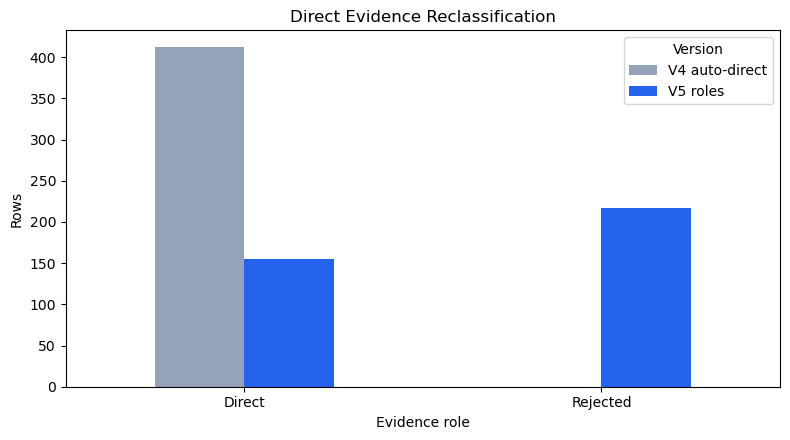

In [36]:
# 可视化v4与v5证据角色数量变化。
plot_counts = pd.DataFrame({
    'V4 auto-direct': [int(v4_direct_rows), 0],
    'V5 roles': [
        int(v5_direct_rows),
        int(evidence_rules['evidence_role_v5'].eq('reject_low_specificity').sum()),
    ],
}, index=['Direct', 'Rejected'])

ax = plot_counts.plot(
    kind='bar', figsize=(8, 4.5), color=['#94A3B8', '#2563EB']
)
ax.set_title('Direct Evidence Reclassification')
ax.set_xlabel('Evidence role')
ax.set_ylabel('Rows')
ax.legend(title='Version')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## How to use the result

- Gold 回归存在 critical failure：只检查失败案例，不进入 07。
- Gold 全部或绝大多数通过：将 `manual_direct_precision_queue_v5.csv` 交给 Codex 审核。
- Green 的充分率略低不构成删除理由；只有出现跨多个议案的系统性缺失，才重新讨论政党范围。
- 07 必须继续保留 `insufficient_evidence`，不能强制每个查询输出支持或反对。